In [30]:
import cv2
import copy
import os
import pickle
import math
from matplotlib import pyplot as plt
from pathlib import Path

In [31]:
# set paths
image_path = "../data/calibr_dataset/WIN_20260520_12_20_05_Pro.jpg"
calibr_file_path = "../data/calibration.pckl"
h_mtx_path = "../data/h_mtx.pckl"

# set params
boardSize = (9, 6)
criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 30, 0.001)

In [32]:
def show_image(image_path):
    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    
    plt.imshow(image)
    plt.title(Path(image_path).stem)
    plt.axis('off')

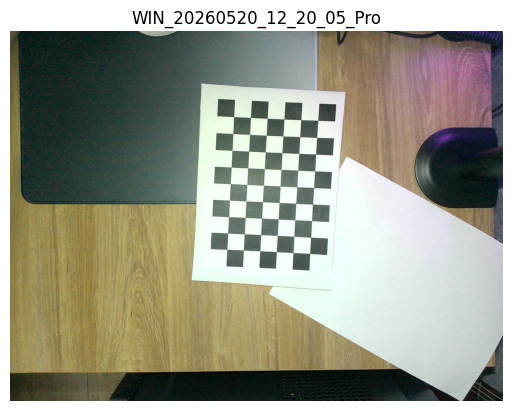

In [33]:
show_image(image_path)

In [34]:
def get_undistored_image(image_path, calibr_file_path):
    
    if not os.path.exists(calibr_file_path):
        raise FileNotFoundError(f"[WARKING] Calibration file not found: {calibr_file_path}")

    with open(calibr_file_path, "rb") as f:
        calibr_results = pickle.load(f)
        
    mtx = calibr_results["mtx"]
    opt_mtx = calibr_results["opt_mtx"]
    dist = calibr_results["dist"]    
    
    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    
    image_undistorted = cv2.undistort(
        image, mtx, dist, None, opt_mtx,
    )
    
    return image_undistorted

In [35]:
def find_board_corners(image, board_size, criteria):
    
    image_cr = copy.deepcopy(image)
    image_gray = cv2.cvtColor(image_cr, cv2.COLOR_RGB2GRAY)
    
    # find board corners
    ret, corners = cv2.findChessboardCorners(
        image_gray, 
        board_size, 
        cv2.CALIB_CB_ADAPTIVE_THRESH + cv2.CALIB_CB_FAST_CHECK + cv2.CALIB_CB_NORMALIZE_IMAGE,
    )
    
    if ret:
        corners2 = cv2.cornerSubPix(
            image_gray, 
            corners, 
            (11,11),
            (-1,-1), 
            criteria,
        )
    else:
        raise ValueError("[WARNING] Chessboard corners not found in image!")
    
    return corners2

In [36]:
image_undistorted = get_undistored_image(image_path, calibr_file_path)
corners = find_board_corners(image_undistorted, boardSize, criteria)

print(corners)

[[[996.1191  300.73767]]

 [[992.57996 355.6787 ]]

 [[989.3119  409.43417]]

 [[986.41724 464.05817]]

 [[983.2254  517.9949 ]]

 [[979.7119  571.4274 ]]

 [[976.6555  625.2896 ]]

 [[973.54767 678.5203 ]]

 [[970.2638  731.15796]]

 [[941.7389  298.55264]]

 [[938.4205  353.13907]]

 [[935.2185  407.19183]]

 [[932.46686 461.35846]]

 [[929.3521  515.3179 ]]

 [[925.86786 568.7568 ]]

 [[922.7552  622.41473]]

 [[919.8494  675.6859 ]]

 [[916.78644 728.3387 ]]

 [[887.4463  296.25165]]

 [[884.3766  350.81375]]

 [[881.3139  404.8905 ]]

 [[878.4359  459.30585]]

 [[875.3106  512.80646]]

 [[872.19025 566.3141 ]]

 [[869.3789  619.80707]]

 [[866.46747 673.1305 ]]

 [[863.3744  725.60376]]

 [[833.6245  293.9352 ]]

 [[830.55896 348.30856]]

 [[827.4622  402.29556]]

 [[824.55096 456.40387]]

 [[821.5346  510.37363]]

 [[818.5728  563.8019 ]]

 [[815.9381  617.3788 ]]

 [[812.64325 670.4711 ]]

 [[809.788   723.126  ]]

 [[779.8225  291.3253 ]]

 [[776.92914 345.70642]]

 [[773.8108 

In [37]:
def get_homography_mtx(h_mtx_path:str):

    if not os.path.exists(h_mtx_path):
        raise FileNotFoundError(f"[WARKING] h_mtx file not found: {h_mtx_path}")

    with open(h_mtx_path, "rb") as f:
        h_mtx_file = pickle.load(f)
        
    h_mtx = h_mtx_file["h_mtx"]   
    
    return h_mtx

In [38]:
def transform_perspective(corners, h_mtx_path, board_size):

    # get homography matrix
    h_mtx = get_homography_mtx(h_mtx_path)

    item_tr_corners = cv2.perspectiveTransform(corners, h_mtx)
    
    item_tr_corners = item_tr_corners.reshape(-1, 2)
    
    # print(f"item_tr_corners:\n{item_tr_corners}")
    
    board_w, board_h = board_size

    print("========== HORIZONTAL DISTANCES ==========")
    
    for row in range(board_h):

        for col in range(board_w - 1):

            idx1 = row * board_w + col
            idx2 = idx1 + 1

            p1 = item_tr_corners[idx1]
            p2 = item_tr_corners[idx2]

            dist = math.hypot(*(p2 - p1))

            print(
                f"row={row}, col={col}: {dist:.2f} mm"
            )
            
    print("========== VERTICAL DISTANCES ==========")
    
    for row in range(board_h - 1):
        for col in range(board_w):

            idx1 = row * board_w + col
            idx2 = idx1 + board_w

            p1 = item_tr_corners[idx1]
            p2 = item_tr_corners[idx2]

            dist = math.hypot(*(p2 - p1))

            print(
                f"row={row}, col={col}: {dist:.2f} mm"
            )

In [39]:
transform_perspective(corners, h_mtx_path, boardSize)

========== HORIZONTAL DISTANCES ==========
row=0, col=0: 22.17 mm
row=0, col=1: 21.78 mm
row=0, col=2: 22.20 mm
row=0, col=3: 22.02 mm
row=0, col=4: 21.90 mm
row=0, col=5: 22.15 mm
row=0, col=6: 21.98 mm
row=0, col=7: 21.82 mm
row=1, col=0: 22.04 mm
row=1, col=1: 21.91 mm
row=1, col=2: 22.03 mm
row=1, col=3: 22.04 mm
row=1, col=4: 21.92 mm
row=1, col=5: 22.08 mm
row=1, col=6: 22.00 mm
row=1, col=7: 21.83 mm
row=2, col=0: 22.04 mm
row=2, col=1: 21.93 mm
row=2, col=2: 22.15 mm
row=2, col=3: 21.87 mm
row=2, col=4: 21.95 mm
row=2, col=5: 22.02 mm
row=2, col=6: 22.04 mm
row=2, col=7: 21.77 mm
row=3, col=0: 21.98 mm
row=3, col=1: 21.91 mm
row=3, col=2: 22.04 mm
row=3, col=3: 22.07 mm
row=3, col=4: 21.93 mm
row=3, col=5: 22.07 mm
row=3, col=6: 21.97 mm
row=3, col=7: 21.86 mm
row=4, col=0: 22.00 mm
row=4, col=1: 21.99 mm
row=4, col=2: 22.15 mm
row=4, col=3: 21.90 mm
row=4, col=4: 22.03 mm
row=4, col=5: 22.04 mm
row=4, col=6: 21.92 mm
row=4, col=7: 21.85 mm
row=5, col=0: 22.02 mm
row=5, col=1: 